In [ ]:
import scanpy as sc
import pandas as pd
import numpy as np
import os
import re
import matplotlib.pyplot as plt
import warnings
import numba
import seaborn as sns
import random
import scipy
from matplotlib.gridspec import GridSpec
import gseapy as gp

sc.set_figure_params(dpi=80)
plt.rcParams["axes.grid"] = False

import matplotlib
matplotlib.rcParams["text.usetex"] = False
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
from matplotlib import rc
rc('font',**{'family':'sans-serif','sans-serif':['DejaVu Sans']})

%config InlineBackend.figure_format='retina'


In [ ]:
import importlib.util
import sys

def lazy_import(module_name, path_to_file):
    spec = importlib.util.spec_from_file_location(module_name,path_to_file)
    foo = importlib.util.module_from_spec(spec)
    sys.modules[module_name] = foo
    spec.loader.exec_module(foo)
    return foo

utils_dir = "../../utils"
general_utils =  lazy_import("general_utils",os.path.join(utils_dir, "general_utils.py"))
anndata_utils = lazy_import("anndata_utils",os.path.join(utils_dir, "anndata_utils.py"))
plotting_functions = lazy_import("plotting_functions",os.path.join(utils_dir, "plotting_functions.py"))
thresholding_functions = lazy_import("thresholding_functions",os.path.join(utils_dir, "thresholding_functions.py"))
gene_signatures_utils = lazy_import("gene_signatures_utils",os.path.join(utils_dir, "gene_signatures.py"))
preprocessing_utils = lazy_import("preprocessing_utils",os.path.join(utils_dir, "preprocessing_utils.py"))
diffusion_maps = lazy_import("diffusion_maps",os.path.join(utils_dir, "diffusion_maps.py"))

from general_utils import ismember, grep
from plotting_functions import plot_individual_category, plot_scatter, plot_signature, plot_gene, get_pseudo_colors, pseudo_color, make_density_map, simple_beeswarm
from anndata_utils import marker_genes_for_cell_group, zscore_with_subset, get_gene, get_genes, annotate_groups
from thresholding_functions import threshold_otsu, threshold_triangle
from gene_signatures_utils import toupper, attach_selected_signatures
from diffusion_maps import get_diffusion_operator_from_knn, getDiffusionComponents, plot_diffusion_components, imputeData, get_imputed_adata_subset


Import data

In [ ]:
adata = sc.read_h5ad("../data/Reyes_injury_SUBSET_all__annotated.h5ad")

Visualize genotype-specific differences

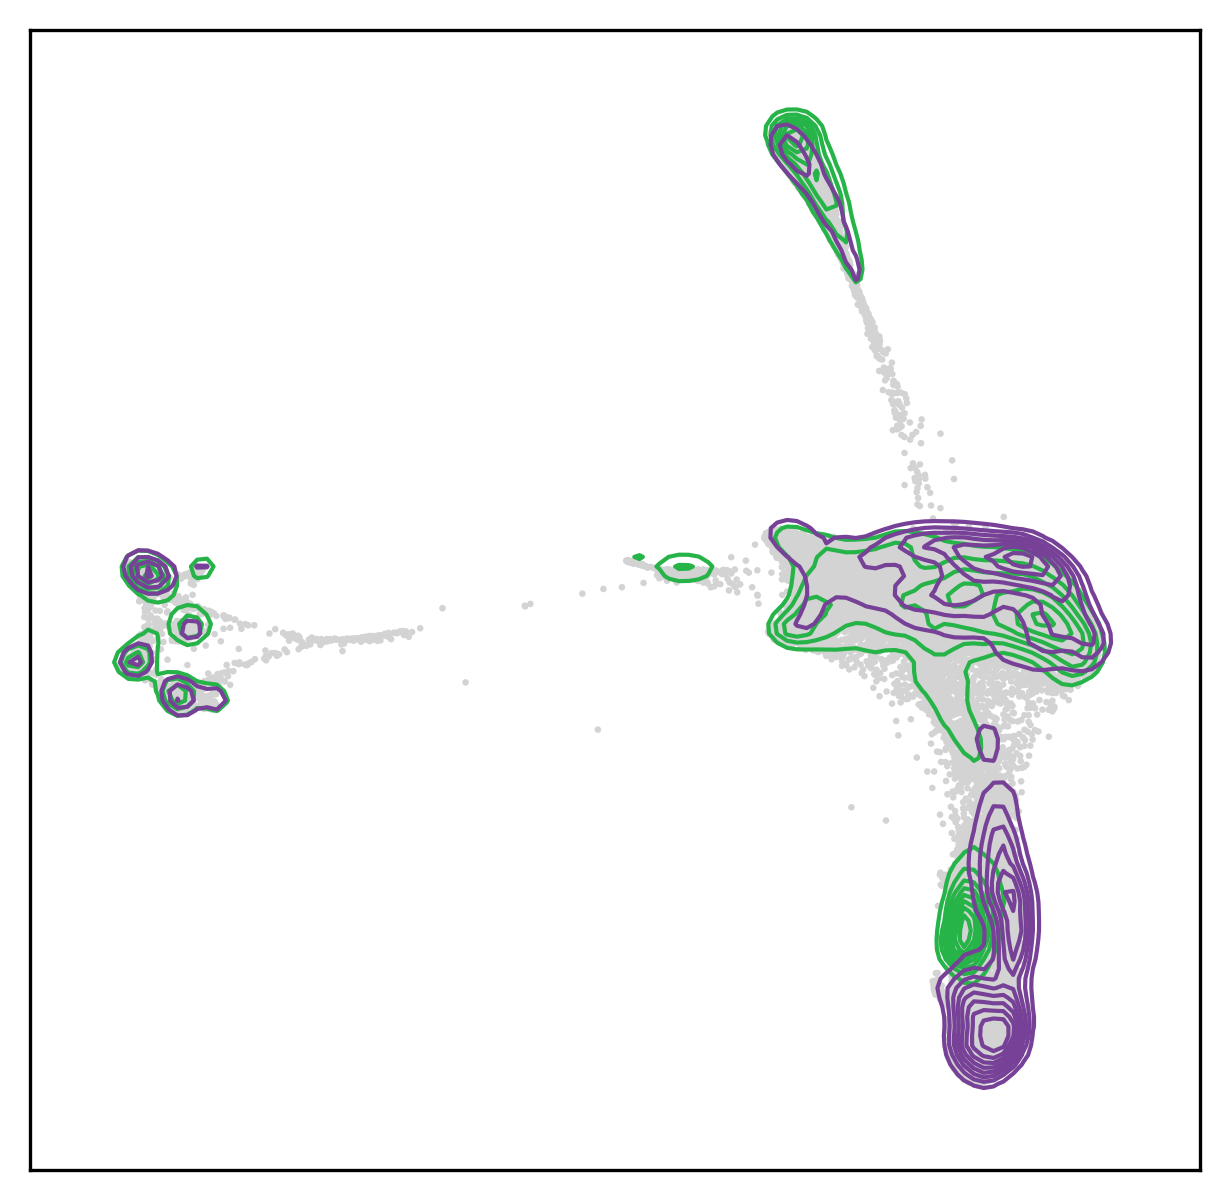

In [ ]:
ax = plot_individual_category(adata, "X_draw_graph_fa", "condition", [], [], figsize_max=5, s = 5, scale_2 = 13, use_outlines=False, background_color='white')
ax = plot_individual_category(adata, "X_draw_graph_fa", "condition", ['K3ctrl', 'K3shp53'], ['lightgray', 'lightgray'], figsize_max=5, s = 0.5, use_outlines=False, background_color='lightgray', ax = ax)

num_contours = 10
x_, y_, z_grid = make_density_map(adata, adata.obs['condition'] == 'K3ctrl', "X_draw_graph_fa", num_contours, "#26B449", background_color = None)
x_, y_, z_grid = make_density_map(adata, adata.obs['condition'] == 'K3shp53', "X_draw_graph_fa", num_contours, "#764196", background_color = None)

Subset adata to focus only on gastric and progenitor-like cells

In [ ]:
selected_cell_types = ismember(adata.obs['cell_type_refined_progenitor_pheno'], ['gastric','gastricprogenitor','progenitor1', 'progenitor2'])[1]
adata = adata[selected_cell_types,:].copy()

Genotype-aware imputation

In [ ]:
imputed_shRen = get_imputed_adata_subset(adata, adata.obs['genotype'] == 'shRen', k = 30)
imputed_shp53 = get_imputed_adata_subset(adata, adata.obs['genotype'] == 'shp53', k = 30)
imputed_adata = sc.concat([imputed_shRen, imputed_shp53])


Getting knn graph


2026-03-02 17:26:59.435243: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-02 17:27:00.579768: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-03-02 17:27:00.579813: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-03-02 17:27:00.654571: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-03-02 17:27:00.688639: I tensorflow/core/platform/cpu_feature_guar

Getting diffusion operator
Computing diffusion kernel using CPU
Computing diffusion operator using CPU
Imputing data
Getting knn graph
Getting diffusion operator
Computing diffusion kernel using CPU
Computing diffusion operator using CPU
Imputing data


In [ ]:
imputed_adata = imputed_adata[adata.obs_names,:].copy()
adata.layers['imputed'] = np.array(imputed_adata.X.copy())
ordering = np.argsort(adata.obs['DC_gastric_progenitor'])
adata = adata[ordering,:].copy()

Compute signatures

I take the z-score using gastric and gastricprogenitor cells as reference for mean and std estimation. Any gene with 0 variance in this subset will get a nan z-score. My signature computation strategy ignores nan when averaging z-score of signature genes

In [ ]:
selected_reference = ismember(adata.obs['cell_type_refined_progenitor_pheno'], ['gastric','gastricprogenitor'])[1]
adata = zscore_with_subset(adata, selected_reference, selected_layer = 'imputed')
adata.layers['zscore'] = adata.layers['zscore_subcells'].copy()

../utils/anndata_utils.py:39: RuntimeWarning: divide by zero encountered in divide
  zscore = np.divide(np.subtract(mat, mean_val), std_val)
../utils/anndata_utils.py:39: RuntimeWarning: invalid value encountered in divide
  zscore = np.divide(np.subtract(mat, mean_val), std_val)


In [ ]:
selected_signatures = ['HALLMARK_EPITHELIAL_MESENCHYMAL_TRANSITION', 'BiegingRolett_p53_TSAG_bound', 'HALLMARK_INTERFERON_GAMMA_RESPONSE', 'Glycolysis_Warburg', 'CORDENONSI_YAP_CONSERVED_SIGNATURE_curated', 'TASDEMIR_p65']
attach_selected_signatures(adata, "../signatures/", selected_signatures, layer = 'zscore')

100%|██████████| 6/6 [00:00<00:00, 33.06it/s]


Plot signature score as a function of gastric-progenitor DC

In [ ]:
DC_rank = np.argsort(adata.obs['DC_gastric_progenitor'])
num_bins = 100
DC_digitized = np.floor(DC_rank / (np.max(DC_rank) / num_bins))
DC_digitized[DC_digitized == num_bins] = num_bins - 1
adata.obs['DC_digitized'] = DC_digitized.copy()
current_signatures = adata.obs[selected_signatures + ['genotype', 'DC_digitized']]


Group by genotype and DC, getting average signature score

In [ ]:
df = current_signatures.groupby(['genotype', 'DC_digitized']).agg('mean')
df.reset_index(inplace = True)

df_shRen = df.loc[df['genotype'] == 'shRen',:].copy()
df_shRen.columns = [x + "_shRen" for x in df_shRen.columns]
df_shp53 = df.loc[df['genotype'] == 'shp53',:].copy()
df_shp53.columns = [x + "_shp53" for x in df_shp53.columns]

df_shRen = df_shRen.iloc[:,2:].copy().reset_index(drop = True)
df_shp53 = df_shp53.iloc[:,2:].copy().reset_index(drop = True)

df = pd.concat((df_shRen, df_shp53), axis=1)
df_signatures = df.iloc[:,np.argsort(df.columns)].copy()

Group by genotype and DC, getting number of cells per combination of these metadata fields

In [ ]:
df = current_signatures.groupby(['genotype', 'DC_digitized']).agg('count')
df.reset_index(inplace = True)

df_shRen = df.loc[df['genotype'] == 'shRen',:].copy()
df_shRen.columns = [x + "_shRen" for x in df_shRen.columns]
df_shp53 = df.loc[df['genotype'] == 'shp53',:].copy()
df_shp53.columns = [x + "_shp53" for x in df_shp53.columns]

df_shRen = df_shRen.iloc[:,2:].copy().reset_index(drop = True)
df_shp53 = df_shp53.iloc[:,2:].copy().reset_index(drop = True)

df = pd.concat((df_shRen, df_shp53), axis=1)
df_counts = df.iloc[:,np.argsort(df.columns)].copy()

Exclude data points supported by fewer than 10 cells

In [ ]:
df_signatures[df_counts < 10] = np.nan

Plot heatmap

/data/lowe/reyesj3/repositories/temp/ipykernel_94522/4117001578.py:40: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()
/data/lowe/reyesj3/repositories/temp/ipykernel_94522/4117001578.py:40: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


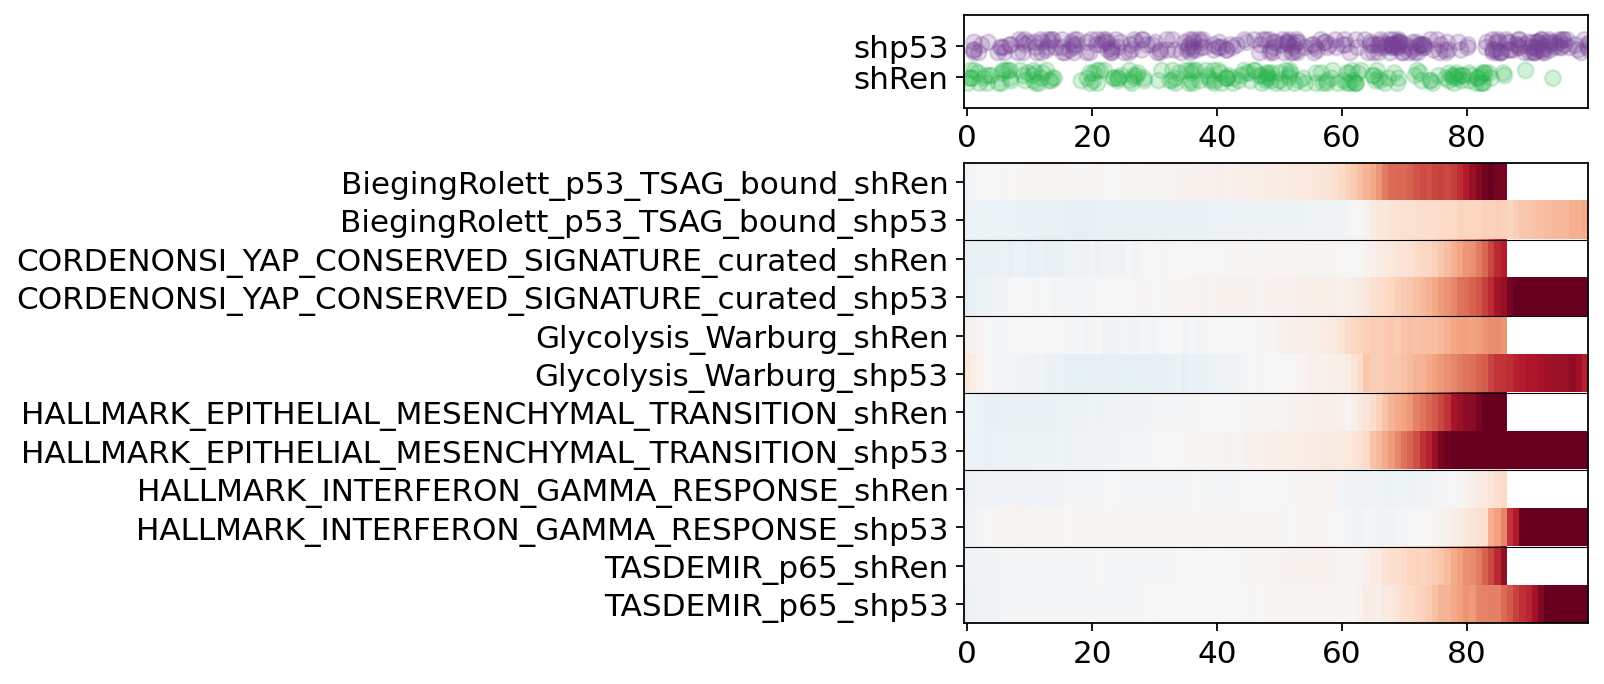

In [ ]:
fig = plt.figure(constrained_layout=True, figsize=[5,5])
spec2 = GridSpec(ncols=1, nrows=2, figure=fig, width_ratios=[1], height_ratios=[0.01, 0.05])
ax1 = fig.add_subplot(spec2[1, 0])
ax2 = fig.add_subplot(spec2[0, 0])

im1 = ax1.imshow(df_signatures.T, aspect = 'auto', interpolation='None', vmin = -5, vmax = 5, cmap="RdBu_r")
#plt.colorbar(im1, label = 'Average z-score')
ax1.set_yticks(list(range(df_signatures.shape[1])), labels = df_signatures.columns)
ax1.grid(False)

xlim = ax1.get_xlim()
for i in range(1, df_signatures.shape[1],2):
    ax1.plot(xlim, [i+0.5] * 2, color='k', linewidth=0.5)

selected_cells = []
for my_genotype in np.unique(adata.obs['genotype']):
    current_cells = np.where(adata.obs['genotype'] == my_genotype)[0]
    selected_cells += random.sample(list(current_cells), k=100)
selected_cells = np.array(selected_cells)

current_cells = list(range(adata.n_obs))
selected_cells = random.sample(current_cells, k=500)

adata.obs['DC_rank_percent'] = DC_rank / (np.max(DC_rank)) * 100
xvals = adata.obs['DC_rank_percent'].to_numpy()

yvals_offset = np.array(ismember(adata.obs['genotype'], np.unique(adata.obs['genotype']))[0])
yvals = simple_beeswarm(xvals)
yvals = np.array([x*0.25 + y for x,y in zip(yvals, yvals_offset)])

colormap = ['#26B449', '#764196']
colors = np.array([colormap[x] for x in yvals_offset])

ax2.scatter(xvals[selected_cells], yvals[selected_cells], s = 50, alpha = 0.2, edgecolor=None, facecolor=colors[selected_cells])
ax2.grid(False)
ax2.set_xlim(xlim)
ax2.set_ylim([-1,2])
ax2.set_yticks([0,1], np.unique(adata.obs['genotype']))

plt.tight_layout()

### Supplemental figures

In [ ]:
adata = sc.read_h5ad("../data/Reyes_injury_SUBSET_all__annotated.h5ad")

In [ ]:
adata_sub = adata[adata.obs['hash_id'] != 'undefined',:].copy()

Progenitor-like cells (fraction of epithelial)

/data/lowe/reyesj3/repositories/temp/ipykernel_94522/734187314.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  tax = sns.barplot(x='condition', y='progenitor', data=progenitor_freq, order=['K3ctrl', 'K3shp53'], palette = ['lightgray', '#5CB647'], saturation=1)


(0.0, 1.0)

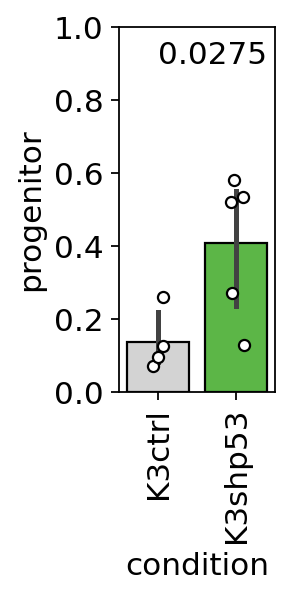

In [ ]:
df = pd.DataFrame({'progenitor': adata_sub.obs['cell_type'] == 'progenitor', 'replicate_id': adata_sub.obs['replicate_id']})
progenitor_freq = df.groupby('replicate_id').agg('mean')
progenitor_freq['condition'] = [re.findall('(K.*?)_', x)[0] for x in progenitor_freq.index]
progenitor_freq['condition'] = [re.sub('K2.0','K2',x) for x in progenitor_freq['condition']]

pval = scipy.stats.ranksums(progenitor_freq['progenitor'][progenitor_freq['condition'] == 'K3ctrl'], progenitor_freq['progenitor'][progenitor_freq['condition'] == 'K3shp53']).pvalue
pval_str = '%.4f' % pval

fig, ax = plt.subplots(1,1, figsize=(1.25,3))# Plot lines for the average
tax = sns.barplot(x='condition', y='progenitor', data=progenitor_freq, order=['K3ctrl', 'K3shp53'], palette = ['lightgray', '#5CB647'], saturation=1)
for patch in tax.patches:
    patch.set_edgecolor('black')
plt.xticks(rotation=90)
sns.stripplot(y="progenitor", x="condition", data=progenitor_freq, ax=ax, color = 'white', edgecolor='black', linewidth=1, order=['K3ctrl', 'K3shp53'])
plt.text(0,0.9,pval_str)
plt.grid(False)
plt.ylim([0,1])

Vim+ Progenitor-like cells (fraction of epithelial)

/data/lowe/reyesj3/repositories/temp/ipykernel_25581/1701831120.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  tax = sns.barplot(x='condition', y='progenitor', data=progenitor_freq, order=['K3ctrl', 'K3shp53'], palette = ['lightgray', '#5CB647'], saturation=1)


(0.0, 1.0)

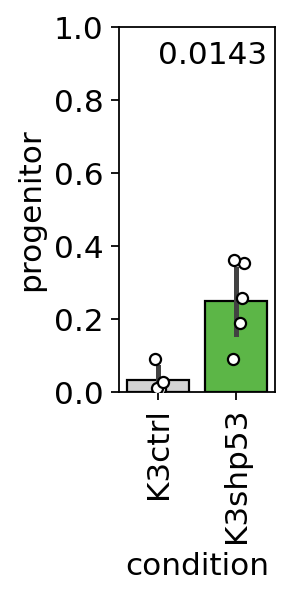

In [ ]:
df = pd.DataFrame({'progenitor': adata_sub.obs['cell_type_refined_progenitor_DC'] == 'progenitor2', 'replicate_id': adata_sub.obs['replicate_id']})
progenitor_freq = df.groupby('replicate_id').agg('mean')
progenitor_freq['condition'] = [re.findall('(K.*?)_', x)[0] for x in progenitor_freq.index]
progenitor_freq['condition'] = [re.sub('K2.0','K2',x) for x in progenitor_freq['condition']]

pval = scipy.stats.ranksums(progenitor_freq['progenitor'][progenitor_freq['condition'] == 'K3ctrl'], progenitor_freq['progenitor'][progenitor_freq['condition'] == 'K3shp53']).pvalue
pval_str = '%.4f' % pval

fig, ax = plt.subplots(1,1, figsize=(1.25,3))# Plot lines for the average
tax = sns.barplot(x='condition', y='progenitor', data=progenitor_freq, order=['K3ctrl', 'K3shp53'], palette = ['lightgray', '#5CB647'], saturation=1)
for patch in tax.patches:
    patch.set_edgecolor('black')
plt.xticks(rotation=90)
sns.stripplot(y="progenitor", x="condition", data=progenitor_freq, ax=ax, color = 'white', edgecolor='black', linewidth=1, order=['K3ctrl', 'K3shp53'])
plt.text(0,0.9,pval_str)
plt.grid(False)
plt.ylim([0,1])

Different comparisons between progenitor-like cells

In [ ]:
cell_type_progenitor_pheno = np.array(['other'] * adata.n_obs, dtype=object)
subcells = np.logical_and(adata.obs['cell_type_refined_progenitor_pheno'] == 'progenitor2', adata.obs['genotype'] == 'shp53')
cell_type_progenitor_pheno[subcells] = 'shp53_progenitor2'
subcells = np.logical_and(adata.obs['cell_type_refined_progenitor_pheno'] == 'progenitor2', adata.obs['genotype'] == 'shRen')
cell_type_progenitor_pheno[subcells] = 'shRen_progenitor2'
subcells = np.logical_and(adata.obs['progenitor_shared_pheno_30'] == True, adata.obs['genotype'] == 'shp53')
cell_type_progenitor_pheno[subcells] = 'shp53_progenitor1'
subcells = np.logical_and(adata.obs['progenitor_shared_pheno_30'] == True, adata.obs['genotype'] == 'shRen')
cell_type_progenitor_pheno[subcells] = 'shRen_progenitor1'
adata.obs['cell_type_progenitor_pheno'] = cell_type_progenitor_pheno.copy()


In [ ]:
shRen_color = '#26B449'
shp53_color = '#764196'
shRen_color = 'limegreen'
shp53_color = 'indigo'
figsize_max = 2
s = 0.5

(-170000.0, -25000.0)

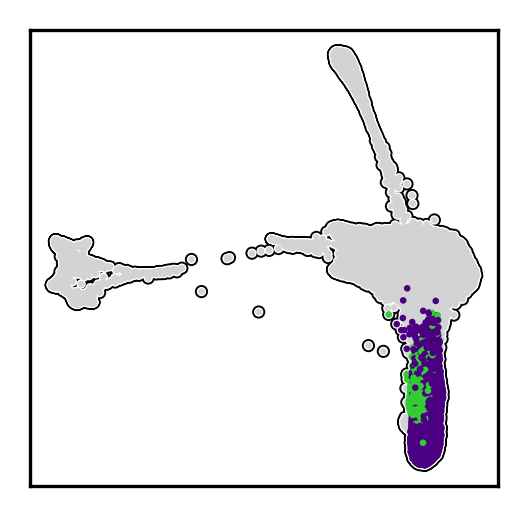

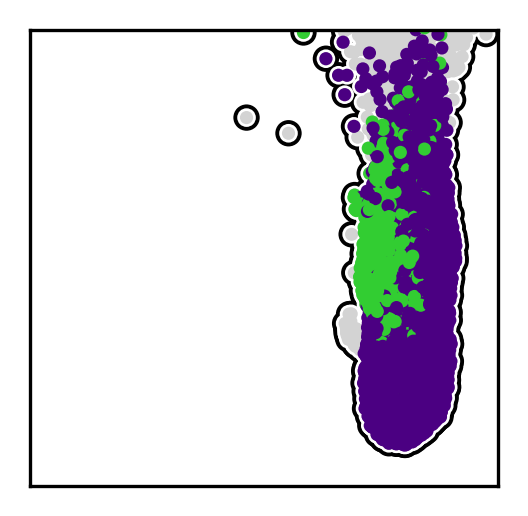

In [ ]:
ax = plot_individual_category(
    adata,"X_draw_graph_fa","cell_type_progenitor_pheno",
    ['shRen_progenitor1', 'shRen_progenitor2', 'shp53_progenitor1', 'shp53_progenitor2'],
    [shRen_color, shRen_color, shp53_color, shp53_color],axes_color='white',s = 0.5,figsize_max=figsize_max,frameon=False,
)

adata_sub = adata[adata.obs['cell_type_refined_progenitor_pheno'] != 'other',:].copy()
ax = plot_individual_category(
    adata_sub,"X_draw_graph_fa","cell_type_progenitor_pheno",
    ['shRen_progenitor1', 'shRen_progenitor2', 'shp53_progenitor1', 'shp53_progenitor2'],
    [shRen_color, shRen_color, shp53_color, shp53_color],
    axes_color='white',figsize_max=figsize_max,frameon=False,s=2
)

plt.xlim([-50000,50000])
plt.ylim([-170000, -25000])

(-170000.0, -25000.0)

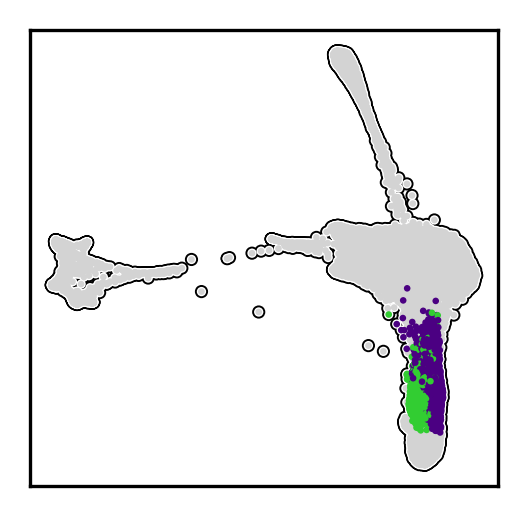

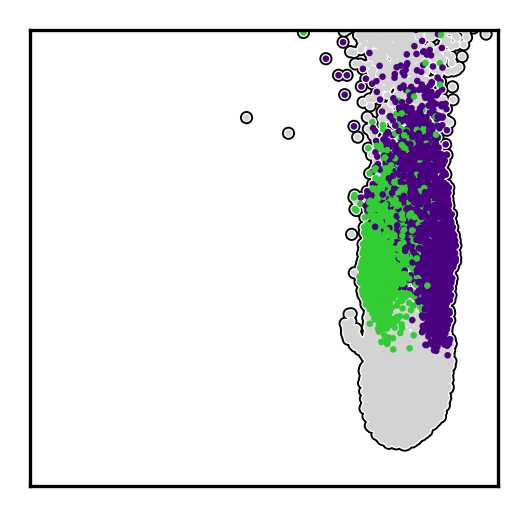

In [ ]:
ax = plot_individual_category(
    adata,"X_draw_graph_fa","cell_type_progenitor_pheno",
    ['shRen_progenitor1', 'shp53_progenitor1'],
    [shRen_color, shp53_color],axes_color='white',s = 0.5,figsize_max=figsize_max,frameon=False,
)

ax = plot_individual_category(
    adata,"X_draw_graph_fa","cell_type_progenitor_pheno",
    ['shRen_progenitor1', 'shp53_progenitor1'],
    [shRen_color, shp53_color],axes_color='white',s = 0.5,figsize_max=figsize_max,frameon=False,
)

plt.xlim([-50000,50000])
plt.ylim([-170000, -25000])

(-170000.0, -25000.0)

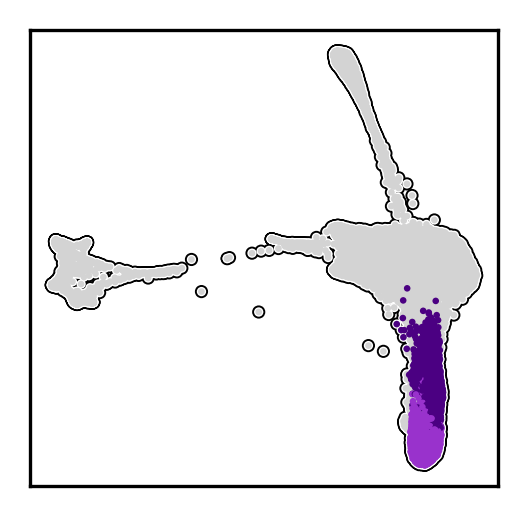

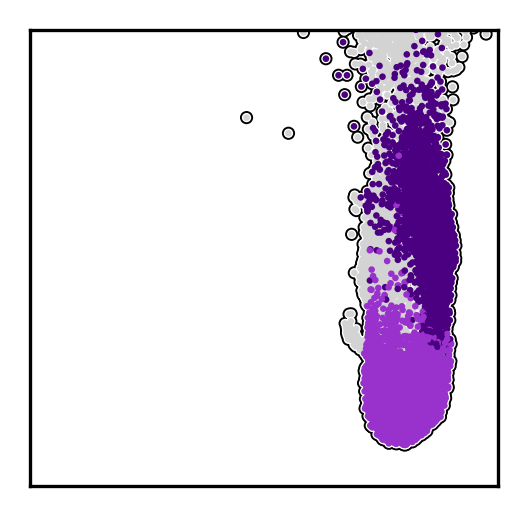

In [ ]:
shp53_color2 = 'darkorchid'

ax = plot_individual_category(
    adata,"X_draw_graph_fa","cell_type_progenitor_pheno",
    ['shp53_progenitor1', 'shp53_progenitor2'],
    [shp53_color, shp53_color2],axes_color='white',s = 0.5,figsize_max=figsize_max,frameon=False,
)

ax = plot_individual_category(
    adata,"X_draw_graph_fa","cell_type_progenitor_pheno",
    ['shp53_progenitor1', 'shp53_progenitor2'],
    [shp53_color, shp53_color2],axes_color='white',s = 0.5,figsize_max=figsize_max,frameon=False,
)

plt.xlim([-50000,50000])
plt.ylim([-170000, -25000])

Expression of p53 targets or epithelial identity genes, depending on which subsets of progenitor-like cells I choose for comparisons

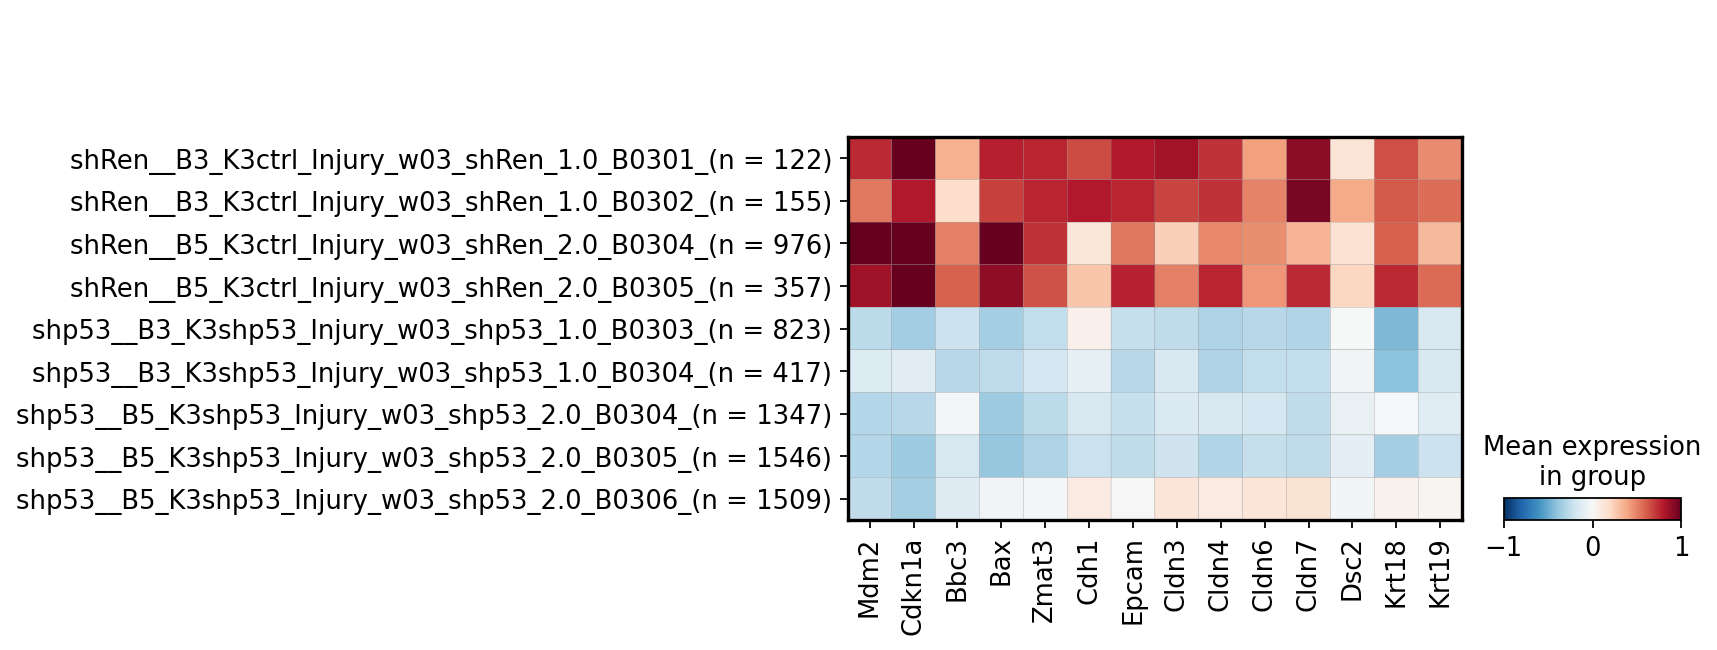

In [ ]:
adata_sub = adata[ismember(adata.obs['cell_type_refined_progenitor_pheno'], ['progenitor1', 'progenitor2'])[1],:].copy()
adata_sub = adata_sub[adata_sub.obs['hash_id'] != "undefined",:].copy()
adata_sub.var_names = [x.capitalize() for x in adata_sub.var_names]
adata_sub.layers['zscore'] = adata_sub.X.copy()
sc.pp.scale(adata_sub, layer = 'zscore')

grouping = ["genotype", "replicate_id"]
annotate_groups(adata_sub, grouping)

selected_genes = ["Mdm2", "Cdkn1a", "Bbc3", "Bax", "Zmat3", "Cdh1", "Epcam", "Cldn3", "Cldn4", "Cldn6", "Cldn7", "Dsc2", "Krt18", "Krt19"]
sc.pl.matrixplot(adata_sub, groupby = "group_id", var_names=selected_genes, cmap = 'RdBu_r', layer = 'zscore', vmin = -1, vmax = 1)


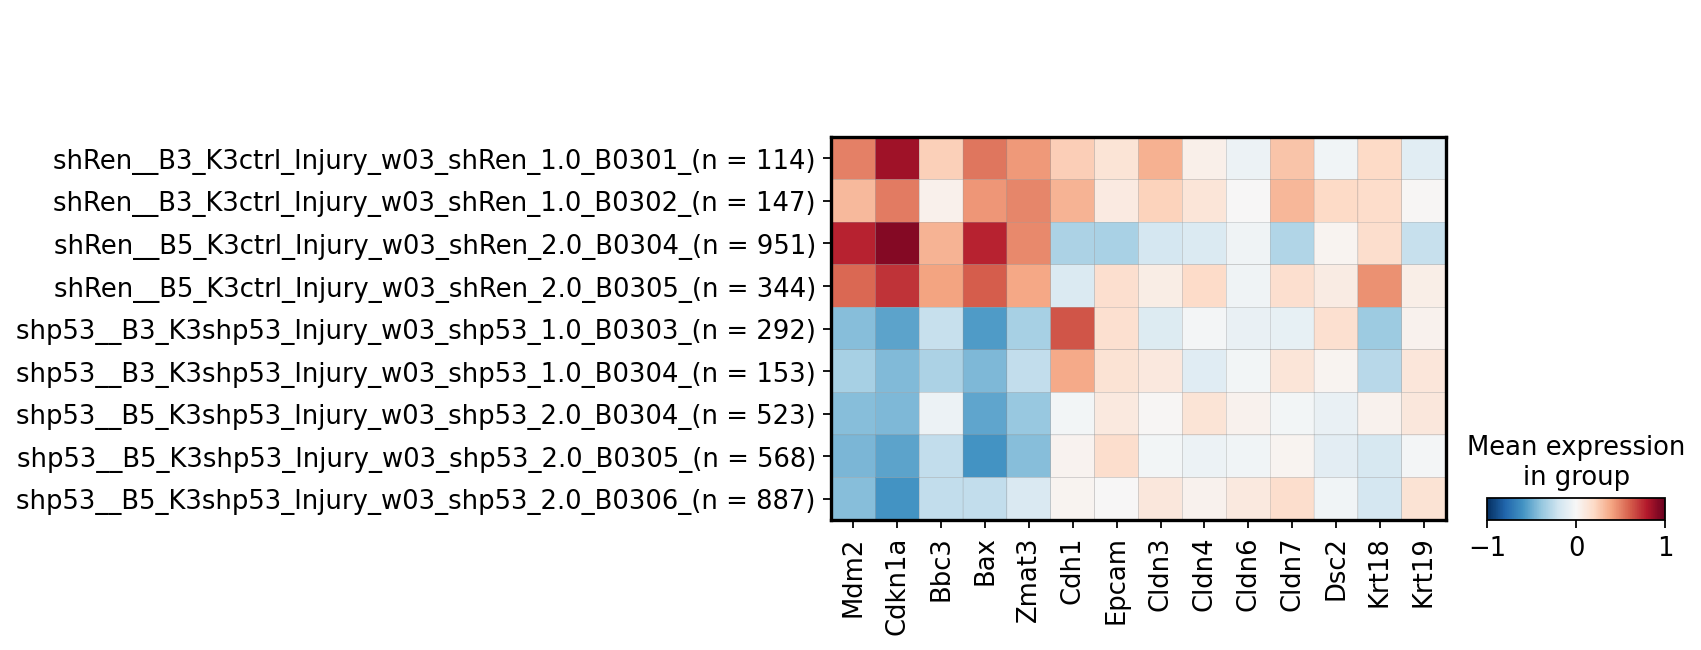

In [ ]:
adata_sub = adata[ismember(adata.obs['progenitor_shared_pheno_30'], [True])[1],:].copy()
adata_sub = adata_sub[adata_sub.obs['hash_id'] != "undefined",:].copy()
adata_sub.var_names = [x.capitalize() for x in adata_sub.var_names]
adata_sub.layers['zscore'] = adata_sub.X.copy()
sc.pp.scale(adata_sub, layer = 'zscore')

grouping = ["genotype", "replicate_id"]
annotate_groups(adata_sub, grouping)

selected_genes = ["Mdm2", "Cdkn1a", "Bbc3", "Bax", "Zmat3", "Cdh1", "Epcam", "Cldn3", "Cldn4", "Cldn6", "Cldn7", "Dsc2", "Krt18", "Krt19"]
sc.pl.matrixplot(adata_sub, groupby = "group_id", var_names=selected_genes, cmap = 'RdBu_r', layer = 'zscore', vmin = -1, vmax = 1)


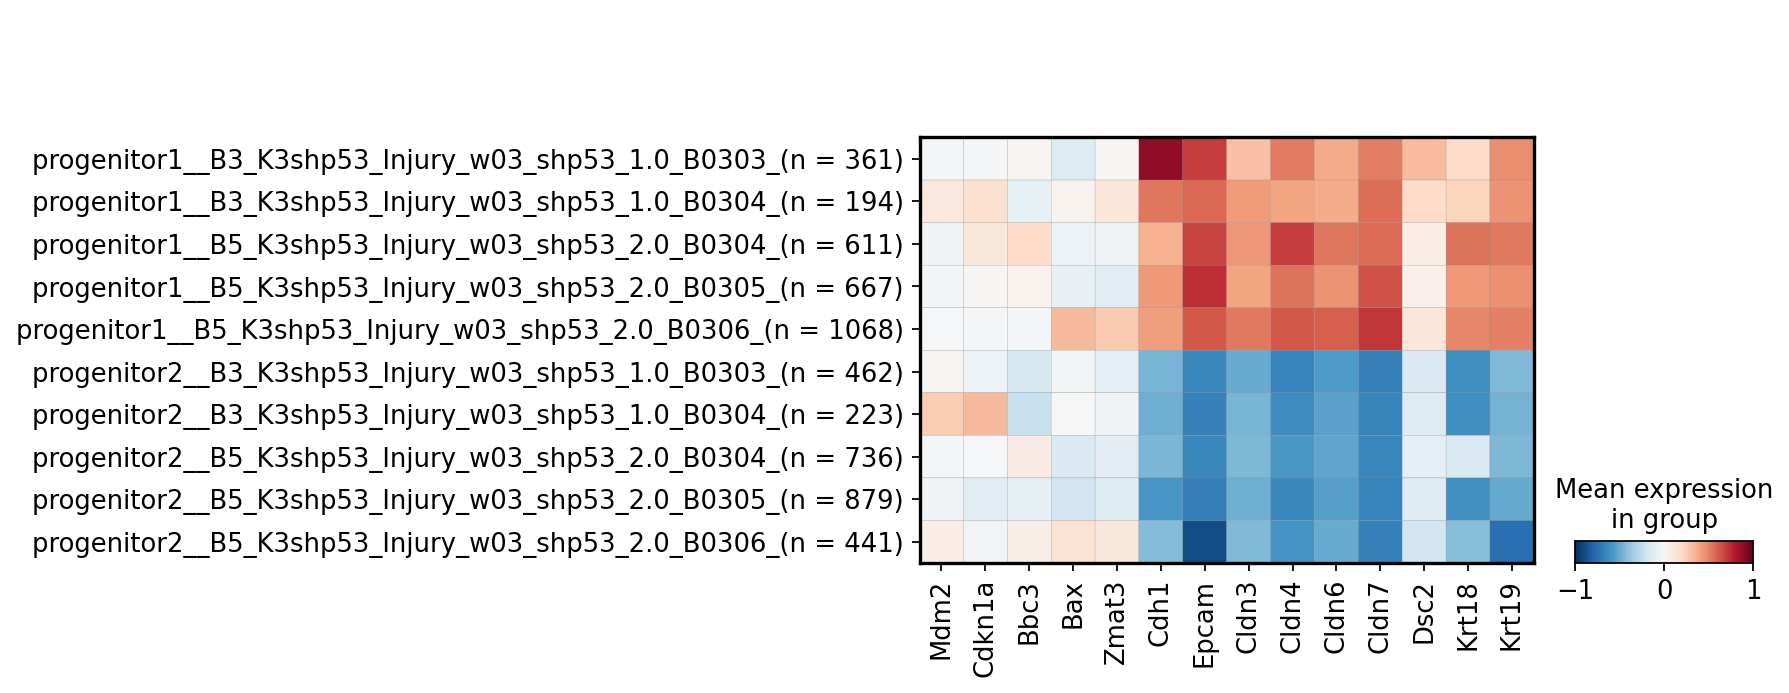

In [ ]:
adata_sub = adata[ismember(adata.obs['genotype'], ['shp53'])[1],:].copy()
adata_sub = adata_sub[ismember(adata_sub.obs['cell_type_refined_progenitor_pheno'], ['progenitor1', 'progenitor2'])[1],:].copy()
adata_sub = adata_sub[adata_sub.obs['hash_id'] != "undefined",:].copy()
adata_sub.var_names = [x.capitalize() for x in adata_sub.var_names]
adata_sub.layers['zscore'] = adata_sub.X.copy()
sc.pp.scale(adata_sub, layer = 'zscore')

grouping = ["cell_type_refined_progenitor_pheno", "replicate_id"]
annotate_groups(adata_sub, grouping)

selected_genes = ["Mdm2", "Cdkn1a", "Bbc3", "Bax", "Zmat3", "Cdh1", "Epcam", "Cldn3", "Cldn4", "Cldn6", "Cldn7", "Dsc2", "Krt18", "Krt19"]
sc.pl.matrixplot(adata_sub, groupby = "group_id", var_names=selected_genes, cmap = 'RdBu_r', layer = 'zscore', vmin = -1, vmax = 1)


### Gene set enrichment analysis of progenitor 2 vs progenitor 1 in p53 deficient samples

In [ ]:
def process_deseq2(filename):
    df = pd.read_csv(filename, index_col = 0)
    df = df.iloc[np.argsort(df['log2FoldChange']),:].copy()
    df.columns = ['baseMean','coef','lfcSE','stat','pval','padj']
    df['gene'] = df.index
    return df

def getGSEA_result(deg, my_gene_set = 'MSigDB_Hallmark_2020', gene_column = 'gene', rank_column = 'log2fc', seed = 0, permutation = 1000):
    pre_res = gp.prerank(rnk=deg.loc[:,[gene_column,rank_column]], gene_sets=my_gene_set, 
                     processes=4,
                     permutation_num=permutation, # reduce number to speed up testing
                     min_size = 8,
                     outdir='test/prerank_report_kegg', format='png', seed = seed)
    return(pre_res)


def plot_GSEA_result(result, fdr_threshold = 0.1, pval_threshold = 0.05, xlim = [-2.5,2.5]):
    result = result.iloc[np.argsort(result['NES']),:]
    result = result.loc[result['FDR q-val'] < fdr_threshold,:]
    result = result.loc[result['NOM p-val'] < pval_threshold,:]

    f = plt.figure(figsize=[5,10/25*result.shape[0]])
    plt.barh(range(result.shape[0]), result['NES'], color = ['red' if x > 0 else 'mediumblue' for x in result['NES']])
    h = plt.yticks(range(result.shape[0]), labels = result['Term'], rotation=0, fontsize=14)
    current_xticks = np.array(f.gca().get_xticks())
    h = plt.xticks(current_xticks[range(0, len(current_xticks), 2)], fontsize=14)
    #plt.axvline(x=0, c='black')
    plt.xlabel("GSEA NES", fontsize=14)
    plt.xlim(xlim)


In [ ]:
de_file = "../differential_expression/injury_shp53/cell_type_refined_progenitor_pheno_genotype_replicate_id/DESEQ20260204_FILTER__cell_type_refined_progenitor_pheno__progenitor2_progenitor1__genotype__shp53__CONTRAST__progenitor1_vs_progenitor2.csv"
df = process_deseq2(de_file)
df = df.loc[np.logical_not(ismember(df['gene'], adata.var_names[adata.var['excluded']]))[1],:].copy()
# Adjust so that I test upregulated in progenitor2
df['coef'] = -df['coef']

In [ ]:
pre_res = getGSEA_result(df, my_gene_set = 'MSigDB_Hallmark_2020', gene_column = 'gene', rank_column = 'coef')

/data/lowe/reyesj3/repositories/temp/ipykernel_25581/1337213769.py:9: DeprecationWarning: processes is deprecated; use threads
  pre_res = gp.prerank(rnk=deg.loc[:,[gene_column,rank_column]], gene_sets=my_gene_set,


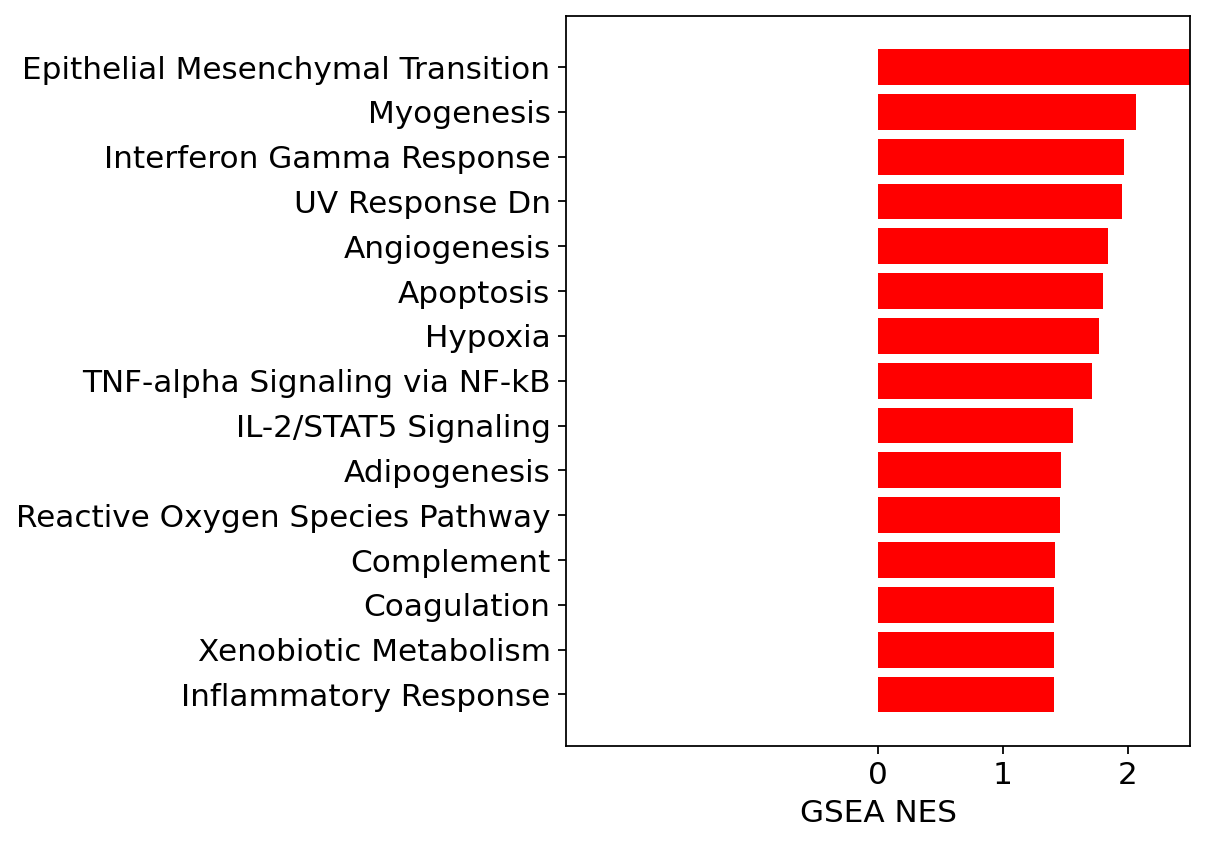

In [ ]:
plot_GSEA_result(pre_res.res2d)